In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import files
uploaded = files.upload()

Saving archive (7).zip to archive (7) (1).zip


In [7]:
import zipfile
import os

zip_file_name = 'archive (7) (1).zip'
extract_dir = 'extracted_data'


os.makedirs(extract_dir, exist_ok=True)


with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)





csv_file_path = os.path.join(extract_dir, 'country_wise_latest.csv')

df = pd.read_csv(csv_file_path)
df.head()

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa


In [10]:
df.isnull().sum()

df = df.dropna()




In [11]:
df.describe()

df['Country/Region'].value_counts().head()

,count
Country/Region,
Afghanistan,1
Albania,1
Algeria,1
Andorra,1
Angola,1


In [12]:
country_cases = df.groupby("Country/Region")["Confirmed"].max()
country_cases = country_cases.sort_values(ascending=False).head(10)

print(country_cases)

Country/Region
US                4290259
Brazil            2442375
India             1480073
Russia             816680
South Africa       452529
Mexico             395489
Peru               389717
Chile              347923
United Kingdom     301708
Iran               293606
Name: Confirmed, dtype: int64


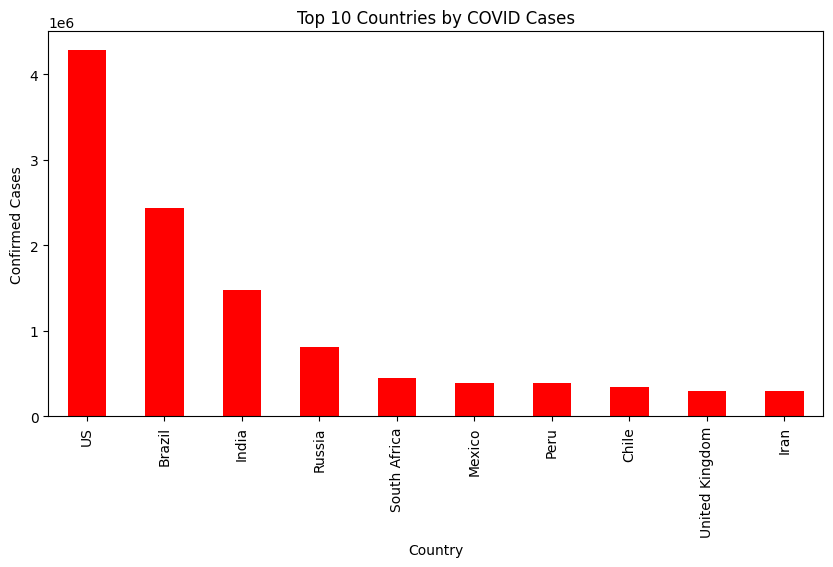

In [13]:
plt.figure(figsize=(10,5))
country_cases.plot(kind='bar',color='red')
plt.title("Top 10 Countries by COVID Cases")
plt.xlabel("Country")
plt.ylabel("Confirmed Cases")
plt.show()

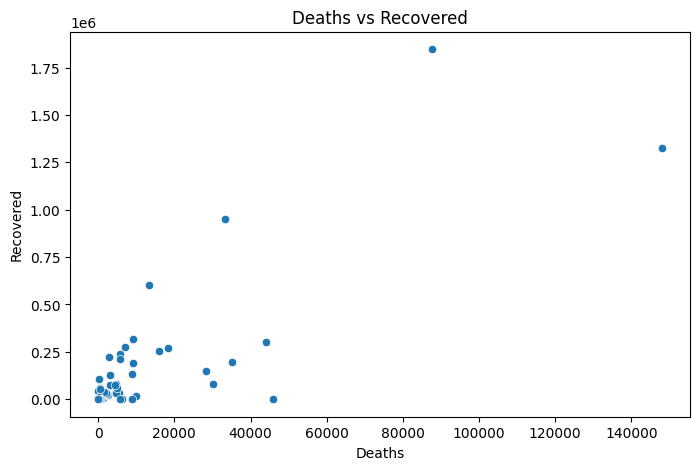

In [14]:
latest = df.groupby("Country/Region").max()

plt.figure(figsize=(8,5))
sns.scatterplot(x=latest["Deaths"], y=latest["Recovered"])
plt.title("Deaths vs Recovered")
plt.show()